# UFC Fight Predictor — Data Exploration & Findings

This notebook is a retrospective companion to the project: it re-runs, in one place, the key data-exploration steps and findings that shaped `src/data_loader.py`, `src/features.py`, and `src/train.py` during development. It isn't part of the production pipeline but a documentation of *why* the pipeline looks the way it does.

Everything here reuses the real project code (`src/`) rather than duplicating logic, so it stays in sync as the project evolves.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import joblib

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 140)

from src.data_loader import load_historical_data, clean_data
from src.features import debias_fighter_order

RAW_PATH = '../data/raw_historical_fights.csv'
CLEANED_PATH = '../data/cleaned_fights.csv'
FEATURES_PATH = '../data/features.csv'

## 1. Loading the Raw Data

First look at the Kaggle historical fights dataset, using the project's own loader.

In [2]:
raw_df = load_historical_data(RAW_PATH)
print('Shape:', raw_df.shape)
raw_df.head(3)

Shape: (8874, 361)


,event_name,referee,winner,num_rounds,title_fight,weight_class,gender,result,result_details,finish_round,finish_time,fight_url,event_date,event_city,event_state,event_country,event_url,f_1_name,f_2_name,f_1_url,f_2_url,f_1_fighter_f_name,f_1_fighter_l_name,f_1_fighter_nickname,f_1_fighter_height_cm,f_1_fighter_weight_lbs,f_1_fighter_reach_cm,f_1_fighter_stance,f_1_fighter_dob,f_1_fighter_w,f_1_fighter_l,f_1_fighter_d,f_1_fighter_nc_dq,f_1_fighter_SlpM,f_1_fighter_Str_Acc,f_1_fighter_SApM,f_1_fighter_Str_Def,f_1_fighter_TD_Avg,f_1_fighter_TD_Acc,f_1_fighter_TD_Def,f_1_fighter_Sub_Avg,f_1_fighter_url,f_2_fighter_f_name,f_2_fighter_l_name,f_2_fighter_nickname,f_2_fighter_height_cm,f_2_fighter_weight_lbs,f_2_fighter_reach_cm,f_2_fighter_stance,f_2_fighter_dob,f_2_fighter_w,f_2_fighter_l,f_2_fighter_d,f_2_fighter_nc_dq,f_2_fighter_SlpM,f_2_fighter_Str_Acc,f_2_fighter_SApM,f_2_fighter_Str_Def,f_2_fighter_TD_Avg,f_2_fighter_TD_Acc,f_2_fighter_TD_Def,f_2_fighter_Sub_Avg,f_2_fighter_url,f_1_knockdowns,f_1_total_strikes_att,f_1_total_strikes_succ,f_1_sig_strikes_att,f_1_sig_strikes_succ,f_1_takedown_att,f_1_takedown_succ,f_1_submission_att,f_1_reversals,f_1_ctrl_time_sec,f_2_knockdowns,f_2_total_strikes_att,f_2_total_strikes_succ,f_2_sig_strikes_att,f_2_sig_strikes_succ,f_2_takedown_att,f_2_takedown_succ,f_2_submission_att,f_2_reversals,f_2_ctrl_time_sec,f_1_r1_sig_pct,f_1_r1_knockdowns,f_1_r1_sig_strikes_succ,f_1_r1_sig_strikes_att,f_1_r1_total_strikes_succ,f_1_r1_total_strikes_att,f_1_r1_td_1_succ,f_1_r1_td_1_att,f_1_r1_td_2,f_1_r1_submission_att,f_1_r1_reversals,f_1_r1_ctrl,f_1_r1_sig_pct_succ,f_1_r1_sig_pct_att,f_1_r1_sig_strikes,f_1_r1_head_succ,f_1_r1_head_att,f_1_r1_body_succ,f_1_r1_body_att,f_1_r1_leg_succ,f_1_r1_leg_att,f_1_r1_distance_succ,f_1_r1_distance_att,f_1_r1_clinch_succ,f_1_r1_clinch_att,f_1_r1_ground_succ,f_1_r1_ground_att,f_1_r2_sig_pct,f_1_r2_knockdowns,f_1_r2_sig_strikes_succ,f_1_r2_sig_strikes_att,f_1_r2_total_strikes_succ,f_1_r2_total_strikes_att,f_1_r2_td_1_succ,f_1_r2_td_1_att,f_1_r2_td_2,f_1_r2_submission_att,f_1_r2_reversals,f_1_r2_ctrl,f_1_r2_sig_pct_succ,f_1_r2_sig_pct_att,f_1_r2_sig_strikes,f_1_r2_head_succ,f_1_r2_head_att,f_1_r2_body_succ,f_1_r2_body_att,f_1_r2_leg_succ,f_1_r2_leg_att,f_1_r2_distance_succ,f_1_r2_distance_att,f_1_r2_clinch_succ,f_1_r2_clinch_att,f_1_r2_ground_succ,f_1_r2_ground_att,f_1_r3_sig_pct,f_1_r3_knockdowns,f_1_r3_sig_strikes_succ,f_1_r3_sig_strikes_att,f_1_r3_total_strikes_succ,f_1_r3_total_strikes_att,f_1_r3_td_1_succ,f_1_r3_td_1_att,f_1_r3_td_2,f_1_r3_submission_att,f_1_r3_reversals,f_1_r3_ctrl,f_1_r3_sig_pct_succ,f_1_r3_sig_pct_att,f_1_r3_sig_strikes,f_1_r3_head_succ,f_1_r3_head_att,f_1_r3_body_succ,f_1_r3_body_att,f_1_r3_leg_succ,f_1_r3_leg_att,f_1_r3_distance_succ,f_1_r3_distance_att,f_1_r3_clinch_succ,f_1_r3_clinch_att,f_1_r3_ground_succ,f_1_r3_ground_att,f_1_r4_sig_pct,f_1_r4_knockdowns,f_1_r4_sig_strikes_succ,f_1_r4_sig_strikes_att,f_1_r4_total_strikes_succ,f_1_r4_total_strikes_att,f_1_r4_td_1_succ,f_1_r4_td_1_att,f_1_r4_td_2,f_1_r4_submission_att,f_1_r4_reversals,f_1_r4_ctrl,f_1_r4_sig_pct_succ,f_1_r4_sig_pct_att,f_1_r4_sig_strikes,f_1_r4_head_succ,f_1_r4_head_att,f_1_r4_body_succ,f_1_r4_body_att,f_1_r4_leg_succ,f_1_r4_leg_att,f_1_r4_distance_succ,f_1_r4_distance_att,f_1_r4_clinch_succ,f_1_r4_clinch_att,f_1_r4_ground_succ,f_1_r4_ground_att,f_1_r5_sig_pct,f_1_r5_knockdowns,f_1_r5_sig_strikes_succ,f_1_r5_sig_strikes_att,f_1_r5_total_strikes_succ,f_1_r5_total_strikes_att,f_1_r5_td_1_succ,f_1_r5_td_1_att,f_1_r5_td_2,f_1_r5_submission_att,f_1_r5_reversals,f_1_r5_ctrl,f_1_r5_sig_pct_succ,f_1_r5_sig_pct_att,f_1_r5_sig_strikes,f_1_r5_head_succ,f_1_r5_head_att,f_1_r5_body_succ,f_1_r5_body_att,f_1_r5_leg_succ,f_1_r5_leg_att,f_1_r5_distance_succ,f_1_r5_distance_att,f_1_r5_clinch_succ,f_1_r5_clinch_att,f_1_r5_ground_succ,f_1_r5_ground_att,f_2_r1_sig_pct,f_2_r1_knockdowns,f_2_r1_sig_strikes_succ,f_2_r1_sig_strikes_att,f_2_r1_total_strikes_succ,f_2_r1_total_strikes_att,f_2_r1_td_1_succ,

### A CSV-quoting lesson

Early on, a naive `wc -l` line count on the raw CSV didn't match the row count pandas loaded. Let's reproduce that directly.

In [3]:
!wc -l ../data/raw_historical_fights.csv
print('pandas loaded rows:', raw_df.shape[0])

    9140 ../data/raw_historical_fights.csv


pandas loaded rows: 8874


The line count is higher than the row count pandas reports. That's not a bug, some text fields in the raw CSV contain embedded newlines *inside quoted values*, so a single fight record can span multiple physical lines. Naive text tools (`wc`, `awk`) count physical lines and get it wrong; `pandas.read_csv` understands CSV quoting and gets the true record count.

## 2. Missing Values

Which columns have gaps, and how big are they?

In [4]:
missing_pct = (raw_df.isnull().mean() * 100).sort_values(ascending=False)
missing_pct.head(25)

f_2_sub_odds               100.000000
f_2_ko_odds                100.000000
f_1_sub_odds               100.000000
f_1_ko_odds                100.000000
f_2_odds                   100.000000
f_1_odds                   100.000000
f_1_r5_clinch_att           96.146045
f_1_r5_leg_succ             96.146045
f_1_r5_leg_att              96.146045
f_1_r5_distance_succ        96.146045
f_1_r5_distance_att         96.146045
f_1_r5_clinch_succ          96.146045
f_1_r5_sig_strikes_succ     96.146045
f_1_r5_ground_succ          96.146045
f_1_r5_ground_att           96.146045
f_1_r5_body_succ            96.146045
f_1_r5_knockdowns           96.146045
f_1_r5_sig_pct              96.146045
f_1_r5_body_att             96.146045
f_1_r5_sig_strikes          96.146045
f_1_r5_head_att             96.146045
f_1_r5_head_succ            96.146045
f_2_r5_sig_pct              96.146045
f_1_r5_sig_pct_att          96.146045
f_1_r5_sig_pct_succ         96.146045
dtype: float64

Three categories emerged from this:

1. **Structurally missing, not a data problem**, e.g. `f_1_r4_*`, `f_1_r5_*` columns are empty whenever a fight ended before round 4/5. That's expected, not an error.
2. **Genuinely sparse**, e.g. `f_1_ranking` / `f_2_ranking` (most fighters were simply never ranked) and the six `*_odds` columns, which turned out to be **100% empty** across the whole dataset.
3. **Critical**: `winner` is missing in a small number of rows. See next section.

## 3. The Missing `winner` Rows — Draw / No Contest

A fight can only be used to train a win/loss classifier if it actually has a winner. Let's check what the rows with a missing `winner` actually are.

In [5]:
missing_winner = raw_df[raw_df['winner'].isnull()]
print('Rows with missing winner:', len(missing_winner))
missing_winner['result'].value_counts()

Rows with missing winner: 156


result
Overturned              59
Decision - Majority     38
Could Not Continue      33
Decision - Split        17
Decision - Unanimous     7
Other                    2
Name: count, dtype: int64

Confirmed: these are Draws and No Contests, fights with no winner by definition. `clean_data()` drops these rows, since a binary win/loss target can't be defined for them.

## 4. Data Leakage #1 — Career Stats Aren't Point-in-Time

`clean_data()` deliberately drops all *in-fight* columns (round-by-round strikes, takedowns, etc.) because they describe what happened **during** a fight, which you can never know before it happens. Using them as prediction features would be leakage.

But there's a subtler leakage lurking in the columns that *are* kept: the career-aggregate stats (`f_1_fighter_w`, `f_1_fighter_SlpM`, etc.). Are they the fighter's record *as of that fight*, or their *current, final* record repeated on every row? Let's check with a fighter who has many fights on file.

In [6]:
fighter = 'Jon Jones'
mask = (raw_df['f_1_name'] == fighter) | (raw_df['f_2_name'] == fighter)
cols = ['event_date', 'f_1_name', 'f_1_fighter_w', 'f_1_fighter_l', 'f_2_name', 'f_2_fighter_w', 'f_2_fighter_l']
raw_df[mask][cols].sort_values('event_date')

,event_date,f_1_name,f_1_fighter_w,f_1_fighter_l,f_2_name,f_2_fighter_w,f_2_fighter_l
7910,2008-08-09,Jon Jones,28,1,Andre Gusmao,6,3
7806,2009-01-31,Jon Jones,28,1,Stephan Bonnar,15,9
7714,2009-07-11,Jon Jones,28,1,Jake O'Brien,15,4
7621,2009-12-05,Matt Hamill,12,8,Jon Jones,28,1
7557,2010-03-21,Jon Jones,28,1,Brandon Vera,15,7
7462,2010-08-01,Jon Jones,28,1,Vladimir Matyushenko,27,8
7325,2011-02-05,Jon Jones,28,1,Ryan Bader,23,5
7288,2011-03-19,Jon Jones,28,1,Mauricio Rua,27,14
7152,2011-09-24,Jon Jones,28,1,Quinton Jackson,37,12
7066,2011-12-10,Jon Jones,28,1,Lyoto Machida,24,8


His win/loss record is identical across *every* fight, from his 2009 debut through his most recent bout, including the fights where he lost. That's the fighter's **final** career record, duplicated on every historical row, not his record as it stood at the time.

**Consequence:** the model implicitly "knows" a fighter's eventual career success even when evaluating their earliest fights, a mild form of leakage for *backtesting* purposes (it likely makes the reported test accuracy slightly optimistic). It does **not** invalidate the live prediction use case, though: when `src/scraper.py` scrapes a fighter's *current* stats for a real prediction, that's the exact same kind of "current snapshot" feature, so train-time and predict-time features stay consistent with each other. Fixing this properly would mean recomputing every fighter's rolling, point-in-time record, judged out of scope for this project, and documented as a known limitation instead.

## 5. Data Leakage #2 — The f_1 / f_2 Winner-Order Bias

This is the biggest one. Is `f_1` just "whichever fighter got listed first", or does it secretly encode something about the outcome?

In [7]:
cleaned_df = clean_data(raw_df)
f1_win_rate_before = (cleaned_df['winner'] == cleaned_df['f_1_name']).mean()
print(f'Share of fights where f_1 is the winner (before de-biasing): {f1_win_rate_before:.1%}')

Share of fights where f_1 is the winner (before de-biasing): 100.0%


**`f_1` is the winner in 100% of fights.** The scraper that built this dataset apparently always lists the winner first. Left as-is, a `target` built from `winner == f_1_name` would be a constant, so the model could get "100% accuracy" by always predicting 1, having learned nothing about fighter comparison. Worse, it would be useless for real prediction, since there's no "winner slot" to assign a fighter to for a fight that hasn't happened yet.

`debias_fighter_order()` fixes this by randomly swapping the `f_1_*` / `f_2_*` columns (as matched pairs, so a fighter's name always stays with their own stats) for ~50% of rows, with a fixed random seed for reproducibility.

In [8]:
debiased_df = debias_fighter_order(cleaned_df)
f1_win_rate_after = (debiased_df['winner'] == debiased_df['f_1_name']).mean()
print(f'Share of fights where f_1 is the winner (after de-biasing): {f1_win_rate_after:.1%}')

Share of fights where f_1 is the winner (after de-biasing): 49.6%


Now close to 50/50. The winner's position is no longer predictable from the column layout alone, so any signal the model picks up has to come from genuine stat differences.

## 6. Engineered Features & Target

A quick look at the final feature set (`data/features.csv`, built by `src/features.py`) and the resulting target balance.

In [9]:
features_df = pd.read_csv(FEATURES_PATH)
print('Shape:', features_df.shape)
print()
print('Target distribution:')
print(features_df['target'].value_counts(normalize=True))

Shape: (8414, 81)

Target distribution:
target
0    0.503803
1    0.496197
Name: proportion, dtype: float64


## 7. Feature Importance

Which features does the saved, trained model actually rely on most?

In [10]:
import glob
model_path = glob.glob('../models/ufc_predictor_*_model.pkl')[0]
model = joblib.load(model_path)
print('Loaded:', model_path)

feature_cols = [c for c in features_df.columns if c not in ('target',) and features_df[c].dtype != object]
# Use exactly the columns the model was trained on, in its own recorded order
feature_cols = list(model.feature_names_in_)

importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
importance

Loaded: ../models/ufc_predictor_RandomForest_model.pkl


win_ratio_diff     0.113089
slpm_diff          0.070156
sapm_diff          0.057488
win_ratio_f1       0.056411
td_def_diff        0.055549
experience_diff    0.054326
win_ratio_f2       0.054150
str_acc_diff       0.050397
age_diff           0.050333
age_f2             0.049670
age_f1             0.048207
total_fights_f1    0.047138
td_avg_diff        0.046442
str_def_diff       0.046229
total_fights_f2    0.043805
td_acc_diff        0.043093
sub_avg_diff       0.037298
reach_diff         0.029292
height_diff        0.026769
weight_diff        0.020160
dtype: float64

<Axes: title={'center': 'Feature importance'}>

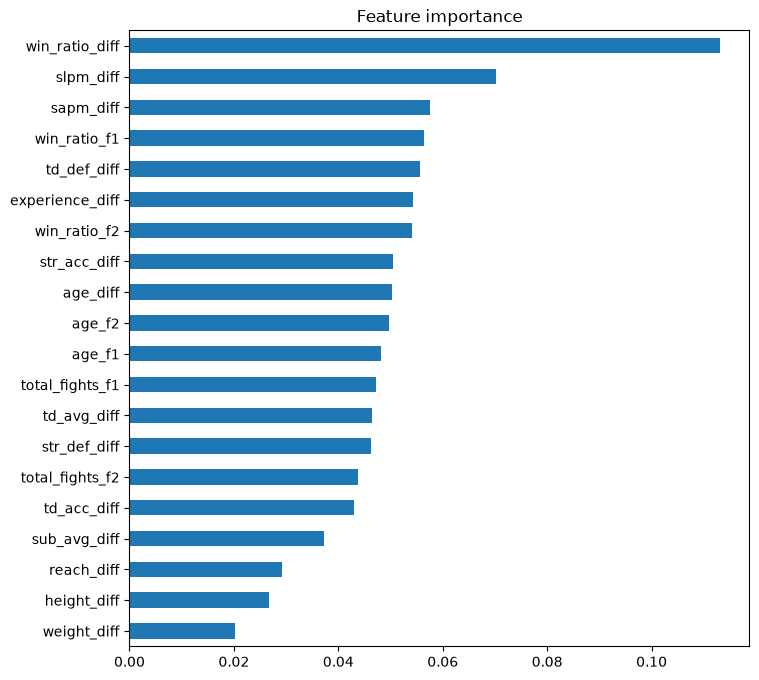

In [11]:
importance.sort_values().plot(kind='barh', figsize=(8, 8), title='Feature importance')

`win_ratio_diff` stands out as the single strongest signal, followed by the striking-output and defensive stats. Physical measurements (`height_diff`, `reach_diff`) matter least, as expected, since real fights are matched within one weight class, so physical differences between opponents are usually small (more on this in the limitations section).

## 8. How Many Trees Does the RandomForest Actually Need?

Rather than guessing `n_estimators`, I used the RandomForest's built-in out-of-bag (OOB) score, which is a free internal validation estimate that comes from the fact each tree only trains on a bootstrapped sample of the rows to compare tree counts directly.

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = features_df[feature_cols]
y = features_df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

for n in [50, 100, 200, 300, 500]:
    rf = RandomForestClassifier(n_estimators=n, random_state=42, oob_score=True)
    rf.fit(X_train, y_train)
    print(f'n_estimators={n}: OOB score = {rf.oob_score_:.4f}')

n_estimators=50: OOB score = 0.6770


n_estimators=100: OOB score = 0.6839


n_estimators=200: OOB score = 0.6969


n_estimators=300: OOB score = 0.7035


n_estimators=500: OOB score = 0.7045


The score climbs noticeably up to ~200 trees, then flattens out. More trees beyond that cost compute without meaningfully improving accuracy. That's why `train.py` uses `n_estimators=200` rather than the sklearn default of 100.

## 9. Which Direction Does Each Feature Actually Favor?

When `predictor.py` reports feature values to a user, it needs to say whether a positive number favors fighter A or fighter B. For most `_diff` features that's intuitive (more striking accuracy = good), but not for all of them — let's check empirically instead of guessing, using each feature's correlation with the target.

In [13]:
diff_cols = [c for c in feature_cols if c.endswith('_diff')]
correlations = features_df[diff_cols].corrwith(features_df['target']).sort_values()
correlations

sapm_diff         -0.175660
age_diff          -0.171286
sub_avg_diff       0.026371
height_diff        0.043689
weight_diff        0.056590
reach_diff         0.065683
experience_diff    0.106553
td_avg_diff        0.128191
td_acc_diff        0.135218
str_acc_diff       0.203998
str_def_diff       0.204879
td_def_diff        0.207074
slpm_diff          0.214003
win_ratio_diff     0.345822
dtype: float64

Two features stand out with a **negative** correlation, meaning a positive raw value actually predicts fighter A losing more often, not winning:

- **`age_diff`** — a positive value means fighter A is *older*. Being older correlates with losing more, matching the general "younger fighter has the edge" pattern in combat sports.
- **`sapm_diff`** — a positive value means fighter A *absorbs more strikes per minute* than fighter B. Getting hit more is bad, not good.

The model itself needed no correction for this — it learns whatever relationship the data shows, positive or negative, on its own. Only the human-facing report in `predictor.py` needed a sign flip for these two, purely so "positive = advantage for fighter A" reads consistently for a human, without changing what actually gets fed into the model.

## 10. Known Limitations (summary)

- **Career stats aren't point-in-time** (Section 4): Reported *test/backtest* accuracy is likely slightly optimistic, since career-aggregate features reflect each fighter's final career totals rather than their record at the time of that specific historical fight. This only matters for *backtesting*, though. For the actual live-prediction use case it's not a workaround at all, it's simply correct: when predicting a real upcoming fight, "current career totals" and "totals as of the fight" are the same thing by definition, since the fight hasn't happened yet. Train-time and predict-time features stay consistent either way.
- **Cross-weight-class "fantasy fight" predictions are unreliable**: Real fights are always matched within one weight class, so `height_diff` / `weight_diff` have very little variance in the training data. A user-requested matchup between fighters from very different weight classes produces feature values far outside anything the tree-based models ever saw, and they extrapolate poorly there. `predictor.py`'s `generate_report()` flags this explicitly when it detects an unusually large height/weight gap.
- **Search is last-name-only**: `src/scraper.py` searches ufcstats.com by last name (full-name queries return no results) and paginates through *all* results (`&page=all`) to find an exact first+last name match, since results are alphabetical and a late-alphabet surname would otherwise be missed on page 1.